# Task 4: Email/SMS Spam Detection with Machine Learning (NLP)

Dataset: SMS Spam Collection Dataset (UCI / Kaggle) — `spam.csv`

Goal: Build a binary text classifier that distinguishes spam messages from legitimate (ham) messages.

## Step 1: Load the Dataset

This dataset is known to be saved with a Latin-1 encoding and has extra unnamed junk columns — we load it carefully and clean it up.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
# This dataset comes with 3 extra unnamed columns full of missing values, and confusing column names (v1, v2)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [14]:
# Keep only the label and message text columns, and rename them clearly
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(5169, 2)

## Step 2: Class Distribution Check (spam vs. ham)

label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


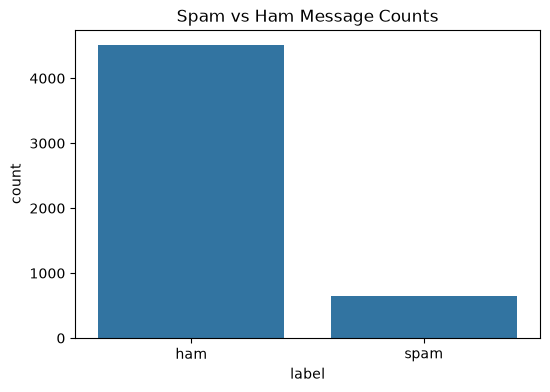

In [16]:
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

print(counts)
print(percentages.round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Message Counts')
plt.show()

**Observation:** This dataset is imbalanced — ham messages significantly outnumber spam messages. Keep this in mind when interpreting accuracy later; a model could get high accuracy just by predicting "ham" every time, which is why precision, recall, and F1-score matter more than raw accuracy for this task.

## Step 3: Text Preprocessing Pipeline

We'll build a cleaning function that:
1. Converts text to lowercase
2. Removes punctuation
3. Removes stopwords (common words like "the", "is", "and" that carry little meaning)
4. Applies stemming (reduces words to their root form, e.g. "running" -> "run")

In [17]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)   # remove numbers
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_message'] = df['message'].apply(clean_text)
df[['message', 'cleaned_message']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tswako\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## Step 4: Feature Extraction with TF-IDF

**What TF-IDF measures:** TF-IDF stands for Term Frequency – Inverse Document Frequency. It converts text into numeric features by scoring each word based on two things: how often it appears in a given message (Term Frequency), and how rare that word is across all messages (Inverse Document Frequency). Words that appear often in one message but rarely across the whole dataset (like "winner" or "claim" in spam messages) get a high score, while very common words that appear everywhere get a low score even if they show up a lot. This helps the model focus on words that are actually distinctive, rather than just common filler words.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_message']).toarray()

y = df['label'].map({'ham': 0, 'spam': 1})

print(X.shape)

(5169, 3000)


## Step 5: Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4135, 3000) (1034, 3000)


## Step 6: Train Classifiers

We train Multinomial Naive Bayes (the industry-standard baseline for text classification) plus Logistic Regression as an alternative for comparison.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nb = MultinomialNB()
nb.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Step 7: Evaluation — Accuracy, Precision, Recall, F1-score, Confusion Matrix

--- Multinomial Naive Bayes ---
Accuracy:  0.9729
Precision: 0.9905
Recall:    0.7939
F1-score:  0.8814



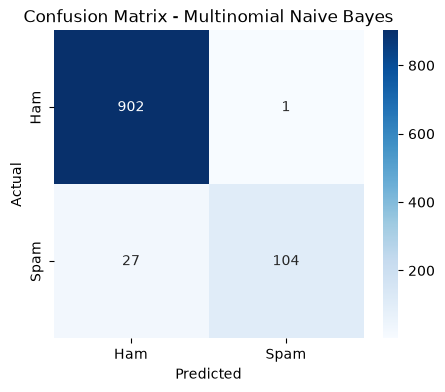

--- Logistic Regression ---
Accuracy:  0.9555
Precision: 1.0000
Recall:    0.6489
F1-score:  0.7870



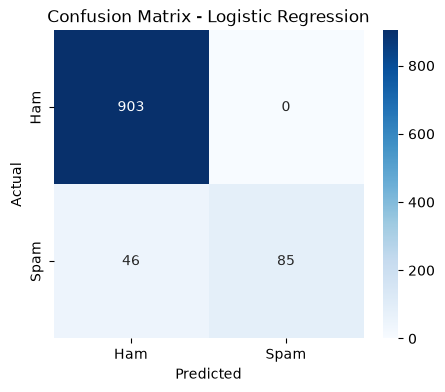

,model,Accuracy,Precision,Recall,F1
0,Multinomial Naive Bayes,0.972921,0.990476,0.793893,0.881356
1,Logistic Regression,0.955513,1.000000,0.648855,0.787037


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print()
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return {'model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

results = []
results.append(evaluate_model(nb, X_test, y_test, 'Multinomial Naive Bayes'))
results.append(evaluate_model(lr, X_test, y_test, 'Logistic Regression'))

results_df = pd.DataFrame(results)
results_df